## Setup

### Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import copy

from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

### Utility Functions

In [ ]:

def do_linear_regression_interactive(model, x, y_obs, optimizer_class=optim.SGD, lr=0.1, nepochs=100):
    

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(step_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))
        optimizer = optimizer_class(model.parameters(), lr=lr)

        # train up to the selected step
        for step in range(step_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(x)
            loss = (y_pred - y_obs).square().mean()
            loss.backward()
            optimizer.step()

        # plot the data and model at this step
        with torch.no_grad():
            y_pred = model(x)
            loss = (y_pred - y_obs).square().mean()

        plt.figure()
        plt.title(f"Data and Model\nstep={step_to_show}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x + model.bias.item(), color="r", label="Model")
        plt.legend()
        plt.show()

    # create slider with steps of 5
    step_slider = widgets.IntSlider(min=0, max=nepochs, step=5, value=0, description='Epoch:')
    widgets.interact(train_and_plot, step_to_show=step_slider)

class utils:
    do_linear_regression_interactive = do_linear_regression_interactive


Run cell below to generate data.

Text(0, 0.5, 'y')

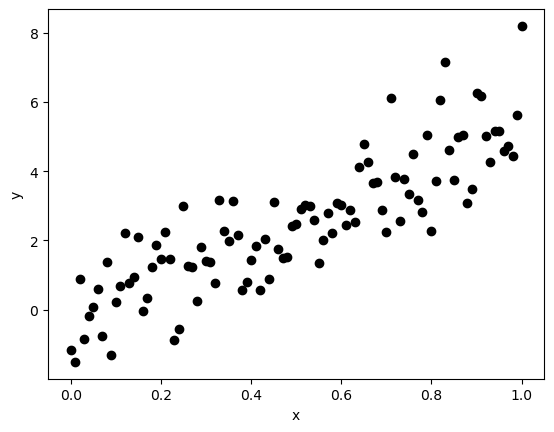

In [ ]:
torch.manual_seed(2025)

x = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*x + torch.randn_like(x)

plt.plot(x, y_obs, 'o', color='black')
plt.xlabel("x")
plt.ylabel("y")

**Demo**: Run the cell below to see a demonstration of linear regression with PyTorch.

In [ ]:
torch.manual_seed(2025)
model = nn.Linear(1,1)

utils.do_linear_regression_interactive(model, x, y_obs)

interactive(children=(IntSlider(value=0, description='Epoch:', step=5), Output()), _dom_classes=('widget-inter…

## Section 1: How to Build a Neural Network Model

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | Creates a single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.Sigmoid()` | Creates a rectified linear unit activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.Sigmoid(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|

**Example**: Create a model with 2 input features and 16 output features.

In [ ]:
nn.Linear(2, 16)

Linear(in_features=2, out_features=16, bias=True)

**Exercise**: Create the model illustrated below, which has 4 input features and 1 output features.

<img src="img/4x1_nn.jpg" width="300">


In [ ]:
nn.Linear(4,1)

Linear(in_features=1, out_features=8, bias=True)

**Exercise**: Create the model illustrated below, which has 8 input features and 2 output features and assign it to a variable called `model`. Print the `model` variable.

<img src="img/8x2_nn.jpg" width="300">

In [ ]:
model = nn.Linear(8,2)
print(model)

Linear(in_features=20, out_features=2, bias=True)


**Exercise**: In the cell below, a vector named `input` with 11 features (here, one feature is a single number) and a model with 11 input features and 1 output feature is created. 

<img src="img/11x1_nn.jpg" width="300">

Pass the variable `input` to the model.

The output from the model should look like this:
`tensor([ -2.8114,],
       grad_fn=<ViewBackward0>)`

In [ ]:
torch.manual_seed(2026)
model = nn.Linear(11,1)

input = torch.linspace(0,10,11)
input

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [ ]:
model(input)

tensor([-2.8114], grad_fn=<ViewBackward0>)

**Exercise**: Run the cell below to generate a new `input` vector that has `21` features. Try to pass this input to the same model. What does the error message say?

In [ ]:
torch.manual_seed(2025)
input = torch.linspace(0,10,21)
input

tensor([ 0.0000,  0.5000,  1.0000,  1.5000,  2.0000,  2.5000,  3.0000,  3.5000,
         4.0000,  4.5000,  5.0000,  5.5000,  6.0000,  6.5000,  7.0000,  7.5000,
         8.0000,  8.5000,  9.0000,  9.5000, 10.0000])

In [34]:
model(input)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x21 and 11x1)

Presumably, you got the following error message: "RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x21 and 11x1)".

You got this error because the dimensions of the `input` vector (1x21) don't match the number of input features in the model (which is 11). The number of input features in the first layer of the model must always be the same as the number of features in the data.

This error message also reveals an important fact about passing inputs through neural network models: It's a matrix multiplication! And when you do matrix multiplication, the dimensions of the matrices (along which the multiplication is carried out) have to match. To fix the issue above, you can create a new model with `21` input features.

**Exercise**: Create a model with 21 input features and 1 output features and assign it to a variable called `model`. Then pass the same input to the model as in the previous exercise. Did it run through now?

**Note**: You will probably get a different output value this time. That's because the initial weights of the model are set randomly and we don't have the same number of weights as before.

In [ ]:
model = nn.Linear(21,1)
model(input)

tensor([-1.9535], grad_fn=<ViewBackward0>)

**Example**: Create the model illustrated below, which has a single hidden layer in addition to the input and output layers. The model should have 2 input features and 1 output feature and the hidden layer should have 4 nodes. Display the model.

<img src="img/2x4x1_nn.jpg" width="300">

In [ ]:
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Linear(4,1)
)
model

Sequential(
  (0): Linear(in_features=11, out_features=32, bias=True)
  (1): Linear(in_features=32, out_features=1, bias=True)
)

**Exercise**: Create a model with a single hidden layer in addition to the input and output layers. The model should have 21 input features and 2 output features and the hidden layer should have 16 nodes. Display the model.

In [36]:
model = nn.Sequential(
    nn.Linear(21,16),
    nn.Linear(16,2)
)
model

Sequential(
  (0): Linear(in_features=21, out_features=16, bias=True)
  (1): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create the model illustrated below, which has two hidden layers in addition to the input and output layers. The model should have 2 input features and 1 output feature and the hidden layers should both have 4 nodes. Display the model.

<img src="img/2x4x2x1_nn.jpg" width="400">

In [ ]:
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Linear(4,2),
    nn.Linear(2,1)
)
model

Sequential(
  (0): Linear(in_features=21, out_features=16, bias=True)
  (1): Linear(in_features=16, out_features=2, bias=True)
)